# Shop Smart Retail Consulting Case

## Data Cleaning (25%)
Investigate and clean the datasets. Possible issues include:
- Duplicate records
- Missing values
- Invalid quantities
- Mixed date formats
- Mixed currency formats
- Inconsistent category and supplier names

Report the following:
1. How many duplicate transactions were removed?
2. How many invalid quantity records were removed?
3. How many records remain after cleaning?
4. What is the total revenue?
5. What is the total gross profit?

In [866]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.dates as mdates

In [648]:
# read in the data as dataframes
sales = pd.read_csv(
    "sales_transactions.csv",
    na_values = ["unknown", "Unknown", "N/A", "nan", "Nan", ""]
)
store = pd.read_csv("store_info.csv")

#### Sales DataFrame: Data Exploration

In [649]:
# explore sales dataframe
print(f"Sales Dataframe Dimensions:\n {sales.shape}\n")
print(f"Sales Dataframe Column Names:\n {sales.columns}\n")
print(f"Sales Dataframe Index:\n {sales.index}\n")
print(f"Sales Dataframe Info:\n {sales.info}\n")
print(f"Sales Dataframe Descriptive Statistics:\n {sales.describe()}\n")
print(f"Sales Dataframe Data Types:\n {sales.dtypes}\n")
sales.head()


Sales Dataframe Dimensions:
 (3085, 12)

Sales Dataframe Column Names:
 Index(['transaction_id', 'store_id', 'sale_date', 'product_category',
       'quantity', 'supplier', 'region', 'unit_cost', 'unit_price',
       'inventory_level', 'labour_hours', 'labour_cost'],
      dtype='str')

Sales Dataframe Index:
 RangeIndex(start=0, stop=3085, step=1)

Sales Dataframe Info:
 <bound method DataFrame.info of      transaction_id store_id            sale_date product_category quantity  \
0           T000571      S06  2025-06-27 00:00:00           Sports        2   
1           T000763      S18  2025-02-14 00:00:00           Beauty        2   
2           T000623      S03                  NaN      Electronics        1   
3           T000827      S27  2025-01-06 00:00:00          Grocery        2   
4           T000175      S01  2025-05-06 00:00:00      Electronics        8   
...             ...      ...                  ...              ...      ...   
3080        T000913      S12  2025-03-25

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31.0,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10.0,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145.0,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14.0,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48.0,5.34,113.35


#### Store DataFrame: Data Exploration

In [650]:
# explore store dataframe
print(f"Store Dataframe Dimensions:\n {store.shape}\n")
print(f"Store Dataframe Column Names:\n {store.columns}\n")
print(f"Store Dataframe Index:\n {store.index}\n")
print(f"Store Dataframe Info:\n {store.info}\n")
print(f"Store Dataframe Descriptive Statistics:\n {store.describe()}\n")
print(f"Store Dataframe Data Types:\n {store.dtypes}\n")
store.head()

Store Dataframe Dimensions:
 (30, 6)

Store Dataframe Column Names:
 Index(['store_id', 'region', 'manager', 'store_size', 'store_type',
       'opening_year'],
      dtype='str')

Store Dataframe Index:
 RangeIndex(start=0, stop=30, step=1)

Store Dataframe Info:
 <bound method DataFrame.info of     store_id  region    manager store_size store_type  opening_year
0        S01    East  Manager_A     Medium     Street          2020
1        S02   South  Manager_B     Medium     Street          2017
2        S03   North  Manager_C      Large     Street          2020
3   Store-04      E   Manager_D      Large     Street          2009
4        S05    East  Manager_E      Small       Mall          2022
5        S06    East  Manager_F     Medium       Mall          2020
6        S07   North  Manager_G      Large     Street          2014
7        S08  South   Manager_H     Medium     Outlet          2021
8        S09    East  Manager_I     Medium       Mall          2018
9         10   SOUTH  

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,Store-04,E,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022


#### Sales DataFrame: How many duplicate transactions were removed?
85 duplicate transactions were removed from the sales dataframe

In [651]:
# check if all transaction IDs have T in them (important when identifying duplicates)
sales["transaction_id"].str.count("T").sum()

# find number of duplicate transactions existing in sales
print(f"Number of Duplicate Records: {sales.duplicated(subset = "transaction_id").sum()}\n")

# view duplicate rows
sales_duplicates = sales[sales.duplicated()]
sales_duplicates

# create a copy of the sales dataframe
sales_clean = sales.copy()

# remove duplicates from sales dataframe
sales_clean = sales_clean.drop_duplicates()

# verify dimensions of the cleaned dataset following removal of duplicates (i.e. since there were 85 duplicates, the dimensions should be (3085 - 85, 12))
print(f"Final Dataframe Dimensions after Removal of Duplicate Records: {sales_clean.shape}")

Number of Duplicate Records: 85

Final Dataframe Dimensions after Removal of Duplicate Records: (3000, 12)


#### Sales DataFrame: How Many Invalid Quantity Records Were Removed?
120 invalid quantity records were removed from the sales dataframe. These values were less than or equal to zero or missing values.

In [652]:
# convert quantities to numeric
sales_clean["quantity"] = pd.to_numeric(sales_clean["quantity"], errors = "coerce")

# check unique quantity records to identify records to be removed
print(f"Unique Quantity Entries Pre-Cleaning: \n {sales_clean['quantity'].unique()}\n")

# identify number of invalid quantity records (i.e. where quantity <= 0 or quantity is nan)
print(f"Number of Invalid Quantity Records: {((sales_clean['quantity'] <= 0) | (sales_clean['quantity'].isna())).sum()}\n")

# check invalid quantity records
sales_invalid_quantity = (sales_clean["quantity"] <= 0) | (sales_clean["quantity"].isna())

# remove invalid quantity records
sales_clean = sales_clean[~sales_invalid_quantity]

Unique Quantity Entries Pre-Cleaning: 
 [ 2.  1.  8.  4.  7.  9. -1.  3.  0.  6.  5. -3. -2. 10. -4. nan -5. -7.
 -6.]

Number of Invalid Quantity Records: 120



#### Sales DataFrame: Inventory Level Cleaning

In [653]:
# convert quantities to numeric
sales_clean["inventory_level"] = pd.to_numeric(sales_clean["inventory_level"], errors = "coerce")

# check unique quantity records to identify records to be removed
print(f"Unique Inventory Levels Pre-Cleaning: \n {sales_clean['inventory_level'].unique()}\n")

# identify number of invalid inventory level records (i.e. where inventory level < 0)
print(f"Number of Invalid Inventory Levels: {(sales_clean['inventory_level'] < 0).sum()}\n")

# convert invalid inventory levels to nan
sales_clean["inventory_level"] = sales_clean["inventory_level"].mask(sales_clean["inventory_level"] < 0)

# identify number of invalid inventory level records following cleaning
print(f"Invalid Inventory Levels Post-Cleaning: {(sales_clean['inventory_level'] < 0).sum()}")

Unique Inventory Levels Pre-Cleaning: 
 [ 31.  10. 145.  14.  48.  63.  19.  83.  50.  20.  76. 105. 155. 121.
 146. 147.  73.  24. 123.  56.  40. 120. -13.  35. 139.  89.  68.   0.
   3.  70.   1.  87.  25. 144.  88.  85.  21. 156.  15.  64.  54.  26.
  44.  16.  11.  47.  34. 154. 134. 106.  37. 153. 107. 151.  39. 108.
  32.  95.  nan  49.  33. 131.  78.  38. 133. 128.  42.  97. 116.  81.
 103. 110.  59.  52.  82. 148.  29. 149. 101.  51.  17. 112. 136. 111.
 104. 124. 138.  13. 114. 119. 117.  80. -16.  69.  23.  12.   7.  36.
  28. 140.   8.   6. 130. 100.  62.  93.  30.  99. 126.   2.  46.  27.
  18. 135.  43.  55. 109. 122.  58.  60.  75.  67. 113.  22.  61.  94.
 102.   4. 118.  96.  91.  -7.  41.  90. 159.  77.  45. 127. 150.  72.
   9.  71. -20. 125. 137. 115.  74. 129.  -2.  57. 142. 141. 157. -10.
   5. 143.  86. 152. 132.  84. -26. -23.  53. 158. -25.  65.  98. -22.
  92.  -6.  66. -28. -11. -18.  79. -17. -27. -21. -29.  -5.  -1. -15.
  -3. -19.]

Number of Invalid Invent

#### Sales DataFrame: String Cleaning/Standardization

In [654]:
# create a list of columns with strings to be cleaned
str_cleaning_columns = ["product_category", "supplier", "region"]

# convert all strings to lowercase and strip whitespace
sales_clean[str_cleaning_columns] = sales_clean[str_cleaning_columns].apply(
    lambda column: column.astype("string").str.strip().str.lower()
)

# check dataframe
sales_clean

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,sports,2.0,activepro,east,59.53,121.7,31.0,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,beauty,2.0,glow works,west,17.62,40.84,10.0,NaN,119.32
2,T000623,S03,NaN,electronics,1.0,northstar,north,235.26,308.8,145.0,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,grocery,2.0,freshfarm,west,6.41,10.74,14.0,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,electronics,8.0,northstar,east,231.33,289.13,48.0,5.34,113.35
...,...,...,...,...,...,...,...,...,...,...,...,...
3080,T000913,S12,2025-03-25 00:00:00,home,1.0,budgetsource,south,38.99,69.56,14.0,3.35,82.53
3081,T001544,S24,2025-02-05 00:00:00,electronics,2.0,northstar,west,226.3,279.87,25.0,4.74,146.84
3082,T000716,S30,2025-04-12 00:00:00,sports,1.0,activepro,west,60.44,118.09,1.0,3.47,115.96
3083,T000678,S01,2025-06-27 00:00:00,apparel,1.0,stylehub,east,28.66,60.4,23.0,5.74,137.09


#### Sales DataFrame: Product Category Cleaning

In [655]:
# check unique product categories to identify issues to address
print(f"Unique Product Categories Pre-Cleaning: \n {sales_clean['product_category'].unique()}\n")

# create dictionary to standardize product categories since there are differences in naming schemes
product_map = {
    "clothing": "apparel",
    "groceries": "grocery",
    "food": "grocery",
    "sports": "sporting goods",
    "beauty": "cosmetics",
    "electronic": "electronics",
    "home": "home goods"
}

# use product_map to replace product categories in the dataframe
sales_clean["product_category"] = sales_clean["product_category"].replace(product_map)

# verify 
print(f"Unique Product Categories Post-Cleaning: \n {sales_clean['product_category'].unique()}")

Unique Product Categories Pre-Cleaning: 
 <StringArray>
[        'sports',         'beauty',    'electronics',        'grocery',
           'home',        'apparel', 'sporting goods',      'groceries',
           'food',     'electronic',     'home goods',       'clothing',
      'cosmetics']
Length: 13, dtype: string

Unique Product Categories Post-Cleaning: 
 <StringArray>
['sporting goods',      'cosmetics',    'electronics',        'grocery',
     'home goods',        'apparel']
Length: 6, dtype: string


#### Sales DataFrame: Supplier Cleaning

In [656]:
# check unique suppliers to identify issues to address
print(f"Unique Suppliers Pre-Cleaning: \n {sales_clean['supplier'].unique()}\n")

# create dictionary to standardize supplier names since there are differences in naming schemes
supplier_map = {
    "activepro": "active pro",
    "glowworks": "glow works",
    "north-star": "north star",
    "northstar": "north star",
    "freshfarm": "fresh farm",
    "budgetsource": "budget source",
    "stylehub": "style hub"
}

# use supplier_map to replace suppliers in the dataframe
sales_clean["supplier"] = sales_clean["supplier"].replace(supplier_map)

# verify 
print(f"Unique Suppliers Post-Cleaning: \n {sales_clean['supplier'].unique()}")

Unique Suppliers Pre-Cleaning: 
 <StringArray>
[    'activepro',    'glow works',     'northstar',     'freshfarm',
  'budgetsource',     'glowworks',      'stylehub',    'north star',
    'north-star', 'budget source',    'active pro',    'fresh farm',
     'style hub']
Length: 13, dtype: string

Unique Suppliers Post-Cleaning: 
 <StringArray>
[   'active pro',    'glow works',    'north star',    'fresh farm',
 'budget source',     'style hub']
Length: 6, dtype: string


#### Sales DataFrame: Region Cleaning

In [657]:
# check unique regions to identify issues to address
print(f"Unique Regions Pre-Cleaning: \n {sales_clean['region'].unique()}")

# there do not seem to be anything that needs to be cleaned with regions

Unique Regions Pre-Cleaning: 
 <StringArray>
['east', 'west', 'north', 'south']
Length: 4, dtype: string


#### Sales DataFrame: Store ID Cleaning

In [658]:
# write a function to standardize store ID
def normalize_store_id(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in ["unknown", "Unknown", "N/A", "nan", "Nan", ""]:
        return pd.NA
    digits = "".join(re.findall(r"\d+", s))
    if digits == "":
        return pd.NA
    return "S" + digits.zfill(2)

# apply function to the store id column in the sales dataframe
sales_clean["store_id"] = sales_clean["store_id"].apply(normalize_store_id)

# verify that all store IDs follow the same naming convention now
print(f"Unique Store IDs Post Cleaning: {sales_clean['store_id'].unique()}")

Unique Store IDs Post Cleaning: <StringArray>
['S06', 'S18', 'S03', 'S27', 'S01', 'S24', 'S28', 'S05', 'S12', 'S21', 'S15',
 'S11', 'S23', 'S16', 'S20', 'S02', 'S22', 'S10', 'S07', 'S13', 'S26', 'S19',
 'S04', 'S08', 'S09', 'S14', 'S29', 'S25', 'S30', 'S17']
Length: 30, dtype: str


#### Sales DataFrame: Date Time Conversions

In [659]:
# convert sales date column to datetime type
sales_clean["sale_date"] = pd.to_datetime(sales_clean["sale_date"], errors = "coerce", format = "mixed")

#### Sales DataFrame: Currency Column Cleaning

In [660]:
# write a function to standardize currencies
def normalize_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["unknown", "n/a", "nan", ""]:
        return np.nan
    s = s.replace("$", "").replace(",", "").replace("cad","").strip()
    val = pd.to_numeric(s, errors = "coerce")
    if pd.isna(val):
        return np.nan
    return val

# create a list of columns with currencies to be cleaned
currency_columns = ["unit_cost", "unit_price", "labour_cost"]

# write a for loop to apply the normalize_money function to each relevant column
for column in currency_columns:
    sales_clean[column] = sales_clean[column].apply(normalize_money)

# convert to numeric
sales_clean[currency_columns] = sales_clean[currency_columns].apply(pd.to_numeric, errors = "coerce")

# check for negative values within the currency columns
(sales_clean[currency_columns] < 0).sum()


unit_cost      0
unit_price     0
labour_cost    0
dtype: int64

#### Sales DataFrame: How Many Records Remain After Cleaning?
2880 records remain after cleaning. Records were only removed if they were duplicates or the quantities were invalid (i.e. less than or equal to zero or missing values).

In [661]:
len(sales_clean)

2880

#### What is the Total Revenue?
The total revenue is $941,694.59.

In [662]:
# revenue is the total amount of money a business brings in from sales before any expenses are deducted
# revenue = quantity * unit_price for all transactions

# create revenue column that lists the revenue for each transaction
sales_clean["revenue"] = sales_clean["quantity"] * sales_clean["unit_price"]

# calculate total revenue for all transactions
print(f"Total Revenue: {sales_clean["revenue"].sum()}")

Total Revenue: 941694.59


#### What is the Total Gross Profit?
The total gross profit is $309,308.93.

In [672]:
# gross profit is the money left over after subtracting the cost of goods sold
# gross profit = revenue - unit_price * quantity

# create gross_profit column that lists the gross profit for each transaction
sales_clean["gross_profit"] = sales_clean["revenue"] - sales_clean["quantity"] * sales_clean["unit_cost"]

# calculate total gross profit for all transactions
print(f"Total Gross Profit: {sales_clean["gross_profit"].sum()}")

Total Gross Profit: 309308.93


### Store DataFrame Cleaning

In [664]:
# create copy of the store dataframe
store_clean = store.copy()

#### Store DataFrame: String Cleaning/Standardization

In [665]:
# create a list of columns with strings to be cleaned
str_cleaning_columns_2 = ["region", "manager", "store_size", "store_type"]

# convert all strings to lowercase and strip whitespace
store_clean[str_cleaning_columns_2] = store_clean[str_cleaning_columns_2].apply(
    lambda column: column.astype("string").str.strip().str.lower()
)

# check dataframe
store_clean

,store_id,region,manager,store_size,store_type,opening_year
0,S01,east,manager_a,medium,street,2020
1,S02,south,manager_b,medium,street,2017
2,S03,north,manager_c,large,street,2020
3,Store-04,e,manager_d,large,street,2009
4,S05,east,manager_e,small,mall,2022
5,S06,east,manager_f,medium,mall,2020
6,S07,north,manager_g,large,street,2014
7,S08,south,manager_h,medium,outlet,2021
8,S09,east,manager_i,medium,mall,2018
9,10,south,manager_j,medium,street,2023


#### Sales DataFrame: Store ID Cleaning

In [666]:
# apply previously defined function to the store id column in the store dataframe
store_clean["store_id"] = store_clean["store_id"].apply(normalize_store_id)

# verify that all store IDs follow the same naming convention now
print(f"Unique Store IDs Post Cleaning: {store_clean['store_id'].unique()}")

Unique Store IDs Post Cleaning: <StringArray>
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11',
 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22',
 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30']
Length: 30, dtype: str


#### Store DataFrame: Region Cleaning

In [667]:
# check unique regions to identify issues to address
print(f"Unique Regions Pre-Cleaning: \n {store_clean['region'].unique()}\n")

# create dictionary to standardize entries
region_map = {
    "e": "east",
    "w": "west"
}

# apply region_map to replace regions in the dataframe
store_clean["region"] = store_clean["region"].replace(region_map)

# check unique regions to identify issues to address
print(f"Unique Regions Post-Cleaning: \n {store_clean['region'].unique()}")

Unique Regions Pre-Cleaning: 
 <StringArray>
['east', 'south', 'north', 'e', 'w', 'west']
Length: 6, dtype: string

Unique Regions Post-Cleaning: 
 <StringArray>
['east', 'south', 'north', 'west']
Length: 4, dtype: string


#### Store DataFrame: Manager Cleaning

In [668]:
# remove "manager_" from entries in manager column and rename managers with symbols for readability
store_clean["manager"] = (
    store_clean["manager"].str.replace("manager_","", regex = False)
    .replace("[", "aa")
    .replace("\\", "bb")
    .replace("]", "cc")
    .replace("^", "dd")
)

# verify
print(f"Unique Managers Post-Cleaning:\n {store_clean['manager'].unique()}")

Unique Managers Post-Cleaning:
 <StringArray>
[ 'a',  'b',  'c',  'd',  'e',  'f',  'g',  'h',  'i',  'j',  'k',  'l',  'm',
  'n',  'o',  'p',  'q',  'r',  's',  't',  'u',  'v',  'w',  'x',  'y',  'z',
 'aa', 'bb', 'cc', 'dd']
Length: 30, dtype: string


#### Store DataFrame: Store Size Cleaning

In [669]:
# check unique store sizes to identify issues to address
print(f"Unique Store Sizes Pre-Cleaning: {store_clean['store_size'].unique()}\n")

# no issues to address

Unique Store Sizes Pre-Cleaning: <StringArray>
['medium', 'large', 'small']
Length: 3, dtype: string



#### Store DataFrame: Store Type Cleaning

In [670]:
# check unique store types to identify issues to address
print(f"Unique Store Types Pre-Cleaning: {store_clean['store_type'].unique()}\n")

# no issues to address

Unique Store Types Pre-Cleaning: <StringArray>
['street', 'mall', 'outlet']
Length: 3, dtype: string



## Business Analysis and Visualizations

In [ ]:
# merge sales and store datasets
business = sales_clean.merge(
    store_clean,
    on = "store_id",
    how = "left",
    validate = "many_to_one",
    suffixes = ("_sales", "_store")
)

# drop duplicate region column
business_clean = business.drop(columns = "region_store")

In [684]:
business_clean

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region_sales,unit_cost,unit_price,inventory_level,labour_hours,labour_cost,revenue,gross_profit,manager,store_size,store_type,opening_year
0,T000571,S06,2025-06-27,sporting goods,2.0,active pro,east,59.53,121.70,31.0,2.76,73.19,243.40,124.34,f,medium,mall,2020
1,T000763,S18,2025-02-14,cosmetics,2.0,glow works,west,17.62,40.84,10.0,NaN,119.32,81.68,46.44,r,medium,outlet,2023
2,T000623,S03,NaT,electronics,1.0,north star,north,235.26,308.80,145.0,4.66,103.05,308.80,73.54,c,large,street,2020
3,T000827,S27,2025-01-06,grocery,2.0,fresh farm,west,6.41,10.74,14.0,4.56,125.60,21.48,8.66,aa,large,outlet,2014
4,T000175,S01,2025-05-06,electronics,8.0,north star,east,231.33,289.13,48.0,5.34,113.35,2313.04,462.40,a,medium,street,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,T000913,S12,2025-03-25,home goods,1.0,budget source,south,38.99,69.56,14.0,3.35,82.53,69.56,30.57,l,large,street,2012
2876,T001544,S24,2025-02-05,electronics,2.0,north star,west,226.30,279.87,25.0,4.74,146.84,559.74,107.14,x,medium,street,2013
2877,T000716,S30,2025-04-12,sporting goods,1.0,active pro,west,60.44,118.09,1.0,3.47,115.96,118.09,57.65,dd,medium,outlet,2019
2878,T000678,S01,2025-06-27,apparel,1.0,style hub,east,28.66,60.40,23.0,5.74,137.09,60.40,31.74,a,medium,street,2020


#### Revenue by Product Category

In [724]:
# group product categories and find the sum of revenue for each
business_revenue_category = business_clean.groupby("product_category", as_index = False)["revenue"].sum().sort_values(by = "revenue", ascending = False)

# format dataframe for ease of plotting
business_revenue_category = business_revenue_category.rename(
    columns = {
        "product_category": "Product Category",
        "revenue": "Revenue"
    }
)

# apply title case to product categories for ease of plotting
business_revenue_category["Product Category"] = business_revenue_category["Product Category"].str.title()

# verify
business_revenue_category

,Product Category,Revenue
2,Electronics,584924.78
4,Home Goods,109559.23
5,Sporting Goods,106638.51
0,Apparel,79736.78
1,Cosmetics,40467.21
3,Grocery,20368.08


Text(0, 0.5, 'Revenue (CAD)')

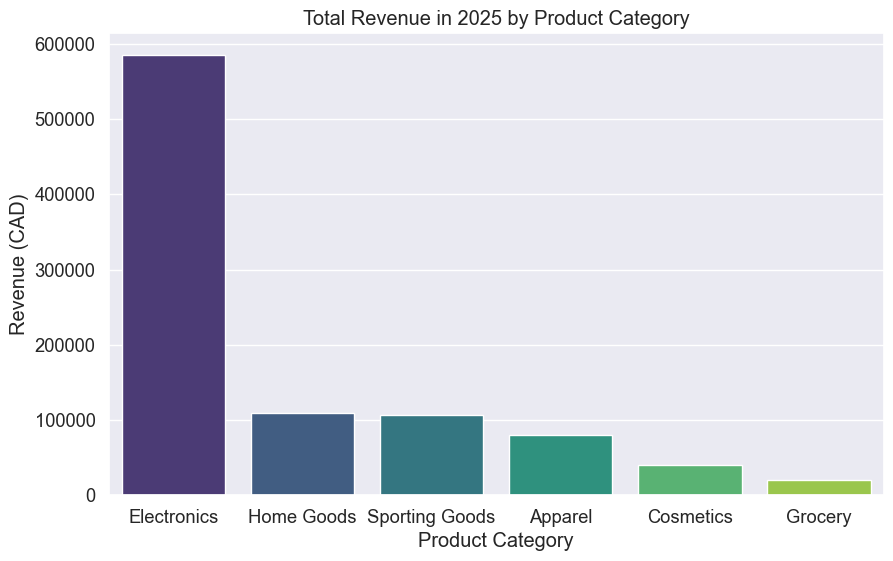

In [ ]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's bar plot
sns.barplot(
    data = business_revenue_category,
    x = "Product Category",
    y = "Revenue",
    hue = "Product Category",
    palette = "viridis"
)

# change graph and axes titles
plt.title("Total Revenue in 2025 by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (CAD)")

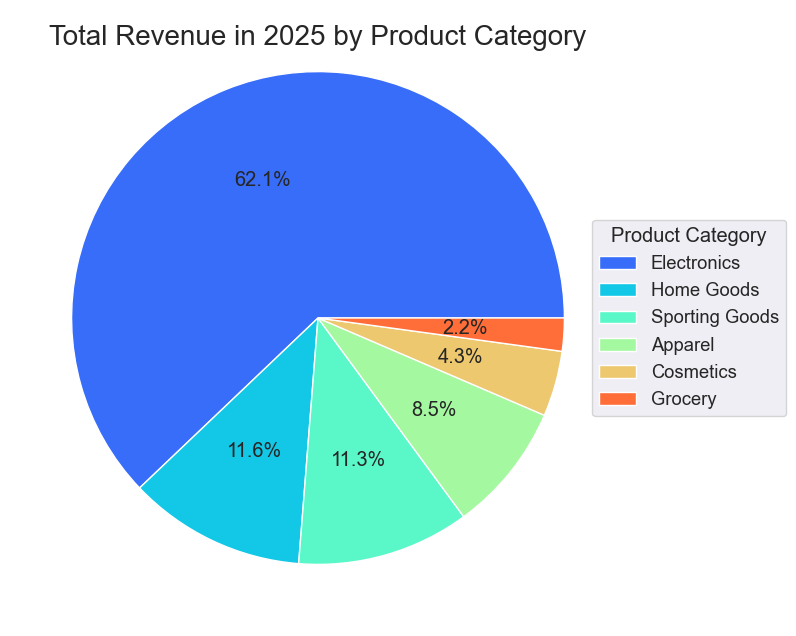

In [829]:
# set plot dimensions
plt.figure(figsize = (15, 8))

# plot using plt's pie chart
plt.pie(
    data = business_revenue_category,
    x = "Revenue",
    colors = sns.color_palette(
        "rainbow",
        n_colors = len(business_revenue_category)
    ),
    autopct = "%1.1f%%"
)

# change graph and axes titles
plt.title(
    "Total Revenue in 2025 by Product Category",
    fontsize = 20,
    x = 0.5,
    y = 0.93
)

# add legend
plt.legend(
    business_revenue_category["Product Category"],
    title = "Product Category",
    loc = "center left",
    bbox_to_anchor = (0.93, 0.5)
)

#### Profit by Product Category

In [ ]:
# group product categories and find the sum of profit for each
business_profit_category = business_clean.groupby("product_category", as_index = False)["gross_profit"].sum().sort_values(by = "gross_profit", ascending = False)

# format dataframe for ease of plotting
business_profit_category = business_profit_category.rename(
    columns = {
        "product_category": "Product Category",
        "gross_profit": "Gross Profit"
    }
)

# apply title case to product categories for ease of plotting
business_profit_category["Product Category"] = business_profit_category["Product Category"].str.title()

# verify
business_profit_category

,Product Category,Gross Profit
2,Electronics,139774.72
5,Sporting Goods,50720.73
4,Home Goods,48689.40
0,Apparel,40980.40
1,Cosmetics,22215.97
3,Grocery,6927.71


Text(0, 0.5, 'Profit (CAD)')

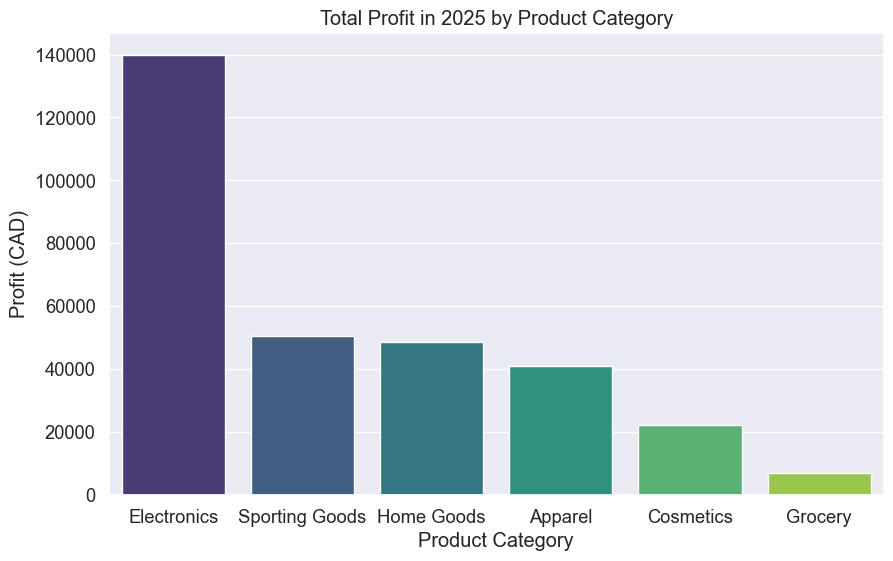

In [831]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's bar plot
sns.barplot(
    data = business_profit_category,
    x = "Product Category",
    y = "Gross Profit",
    hue = "Product Category",
    palette = "viridis"
)

# change graph and axes titles
plt.title("Total Profit in 2025 by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit (CAD)")

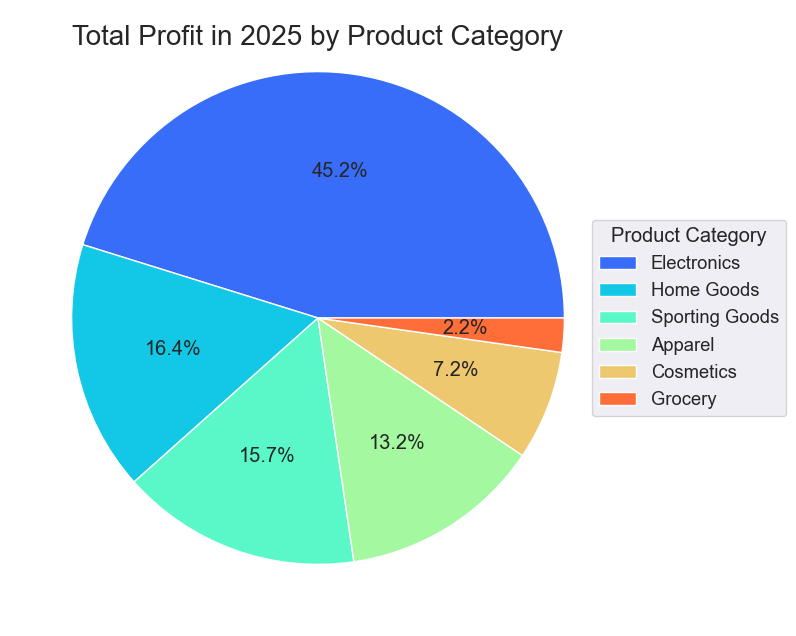

In [832]:
# set plot dimensions
plt.figure(figsize = (15, 8))

# plot using plt's pie chart
plt.pie(
    data = business_profit_category,
    x = "Gross Profit",
    colors = sns.color_palette(
        "rainbow",
        n_colors = len(business_profit_category)
    ),
    autopct = "%1.1f%%"
)

# change graph and axes titles
plt.title(
    "Total Profit in 2025 by Product Category",
    fontsize = 20,
    x = 0.5,
    y = 0.93
)

# add legend
plt.legend(
    business_revenue_category["Product Category"],
    title = "Product Category",
    loc = "center left",
    bbox_to_anchor = (0.93, 0.5)
)

#### Profit by Region

In [ ]:
# group regions and find the sum of profit for each
business_profit_region = business_clean.groupby("region_sales", as_index = False)["gross_profit"].sum().sort_values(by = "gross_profit", ascending = False)

# format dataframe for ease of plotting
business_profit_region = business_profit_region.rename(
    columns = {
        "region_sales": "Region",
        "gross_profit": "Gross Profit"
    }
)

# apply title case to regions for ease of plotting
business_profit_region["Region"] = business_profit_region["Region"].str.title()

# verify
business_profit_region

,Region,Gross Profit
2,South,103271.98
3,West,87391.76
0,East,74494.62
1,North,44150.57


Text(0, 0.5, 'Revenue (CAD)')

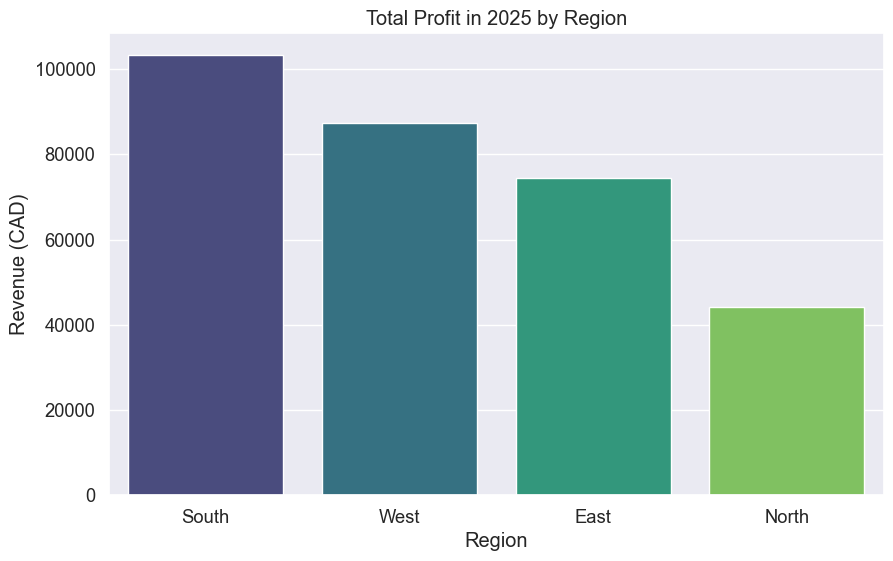

In [ ]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's bar plot
sns.barplot(
    data = business_profit_region,
    x = "Region",
    y = "Gross Profit",
    hue = "Region",
    palette = "viridis"
)

# change graph and axes titles
plt.title("Total Profit in 2025 by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (CAD)")

#### Number of Transactions per Region

In [843]:
# count number of transactions per region
transactions_per_region = business_clean["region_sales"].value_counts().reset_index()

# format dataframe for ease of plotting
transactions_per_region = transactions_per_region.rename(
    columns = {
        "region_sales": "Region",
        "count": "Count"
    }
)

# apply title case to regions for ease of plotting
transactions_per_region["Region"] = transactions_per_region["Region"].str.title()

# verify
transactions_per_region

,Region,Count
0,West,921
1,South,909
2,East,643
3,North,407


Text(0, 0.5, 'Number of Transactions')

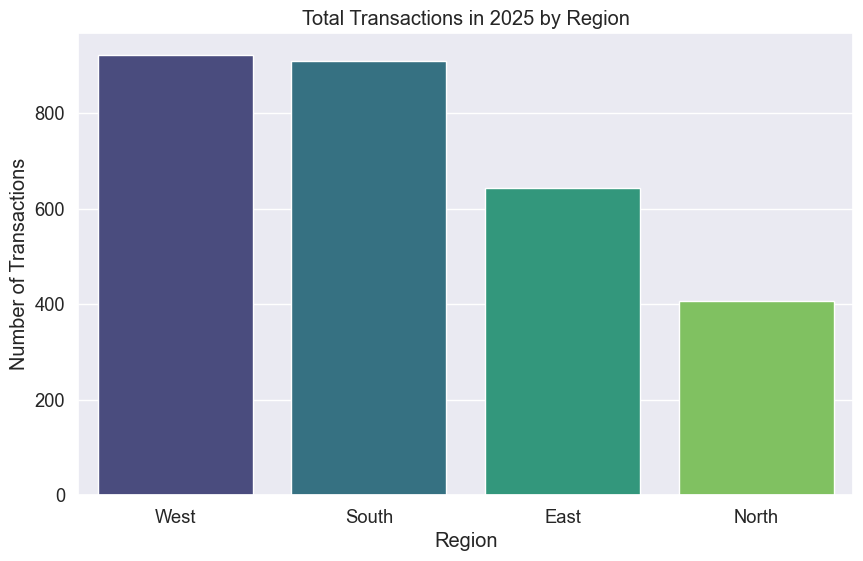

In [844]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's bar plot
sns.barplot(
    data = transactions_per_region,
    x = "Region",
    y = "Count",
    hue = "Region",
    palette = "viridis"
)

# change graph and axes titles
plt.title("Total Transactions in 2025 by Region")
plt.xlabel("Region")
plt.ylabel("Number of Transactions")

#### Stores Per Region

In [855]:
# create dataframe of stores per region
stores_per_region = (
    business_clean
    .groupby("region_sales")["store_id"]
    .nunique()
    .reset_index()
    .sort_values(by = "store_id", ascending = False)
)

# format dataframe for ease of plotting
stores_per_region = stores_per_region.rename(
    columns = {
        "region_sales": "Region",
        "store_id": "Store Count"
    }
)

# apply title case to regions for ease of plotting
stores_per_region["Region"] = stores_per_region["Region"].str.title()

# verify
stores_per_region

,Region,Store Count
2,South,10
3,West,9
0,East,7
1,North,4


Text(0, 0.5, 'Number of Stores')

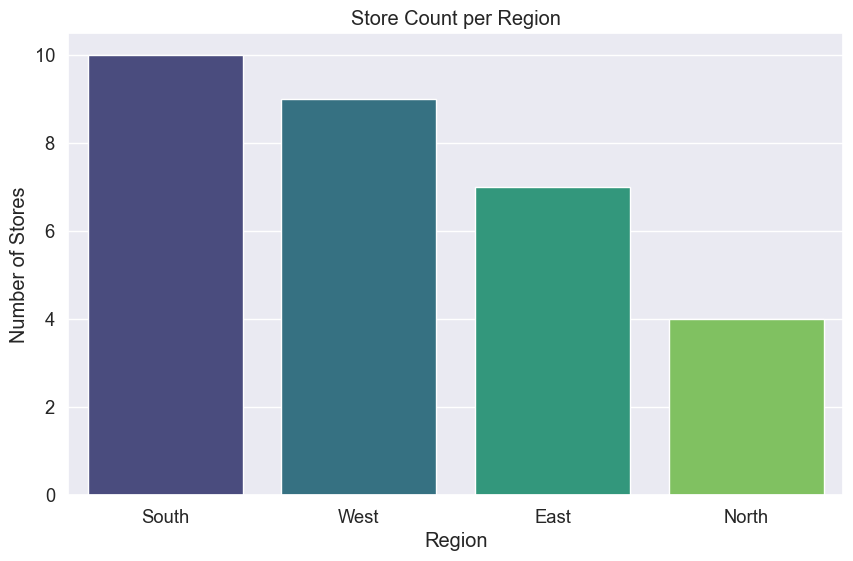

In [856]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's bar plot
sns.barplot(
    data = stores_per_region,
    x = "Region",
    y = "Store Count",
    hue = "Region",
    palette = "viridis"
)

# change graph and axes titles
plt.title("Store Count per Region")
plt.xlabel("Region")
plt.ylabel("Number of Stores")

#### Total Profit by Region and Store Type

In [764]:
# group region and store types and find the sum of revenue for each
region_type_profit = (business_clean.groupby(["region_sales", "store_type"], as_index = False)["revenue"].sum())

# format dataframe for ease of plotting
region_type_profit = region_type_profit.rename(
    columns = {
        "region_sales": "Region",
        "store_type": "Store Type",
        "revenue": "Revenue"
    }
)

# apply title case to regions and store types for ease of plotting
region_type_profit["Region"] = region_type_profit["Region"].str.title()
region_type_profit["Store Type"] = region_type_profit["Store Type"].str.title()

# verify
region_type_profit

,Region,Store Type,Revenue
0,East,Mall,91659.48
1,East,Outlet,33301.81
2,East,Street,96825.68
3,North,Mall,76748.18
4,North,Street,59532.84
5,South,Mall,134281.21
6,South,Outlet,95548.70
7,South,Street,82045.26
8,West,Outlet,213807.21
9,West,Street,57944.22


Text(0, 0.5, 'Revenue (CAD)')

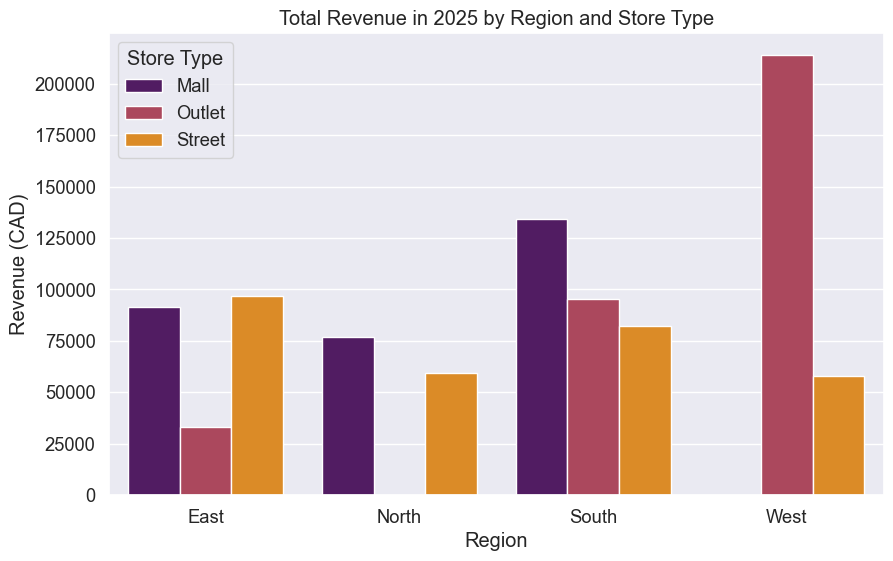

In [792]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot using seaborn's barplot
sns.barplot(
    data = region_type_profit,
    x = "Region",
    y = "Revenue",
    hue = "Store Type",
    palette = "inferno"
)

# change graph and axes titles
plt.title("Total Revenue in 2025 by Region and Store Type")
plt.xlabel("Region")
plt.ylabel("Revenue (CAD)")

#### Total Profit by Region and Product Categories

In [788]:
# group region and product categories and find the sum of revenue for each
region_category_profit = (business_clean.groupby(["region_sales", "product_category"], as_index = False)["revenue"].sum())

# format dataframe for ease of plotting
region_category_profit = region_category_profit.rename(
    columns = {
        "region_sales": "Region",
        "product_category": "Product Category",
        "revenue": "Revenue"
    }
)

# apply title case to regions and product categories for ease of plotting
region_category_profit["Region"] = region_category_profit["Region"].str.title()
region_category_profit["Product Category"] = region_category_profit["Product Category"].str.title()

# verify
region_category_profit

,Region,Product Category,Revenue
0,East,Apparel,16627.96
1,East,Cosmetics,11971.47
2,East,Electronics,137182.63
3,East,Grocery,5120.53
4,East,Home Goods,23428.74
5,East,Sporting Goods,27455.64
6,North,Apparel,10114.85
7,North,Cosmetics,6405.42
8,North,Electronics,88788.73
9,North,Grocery,3495.42


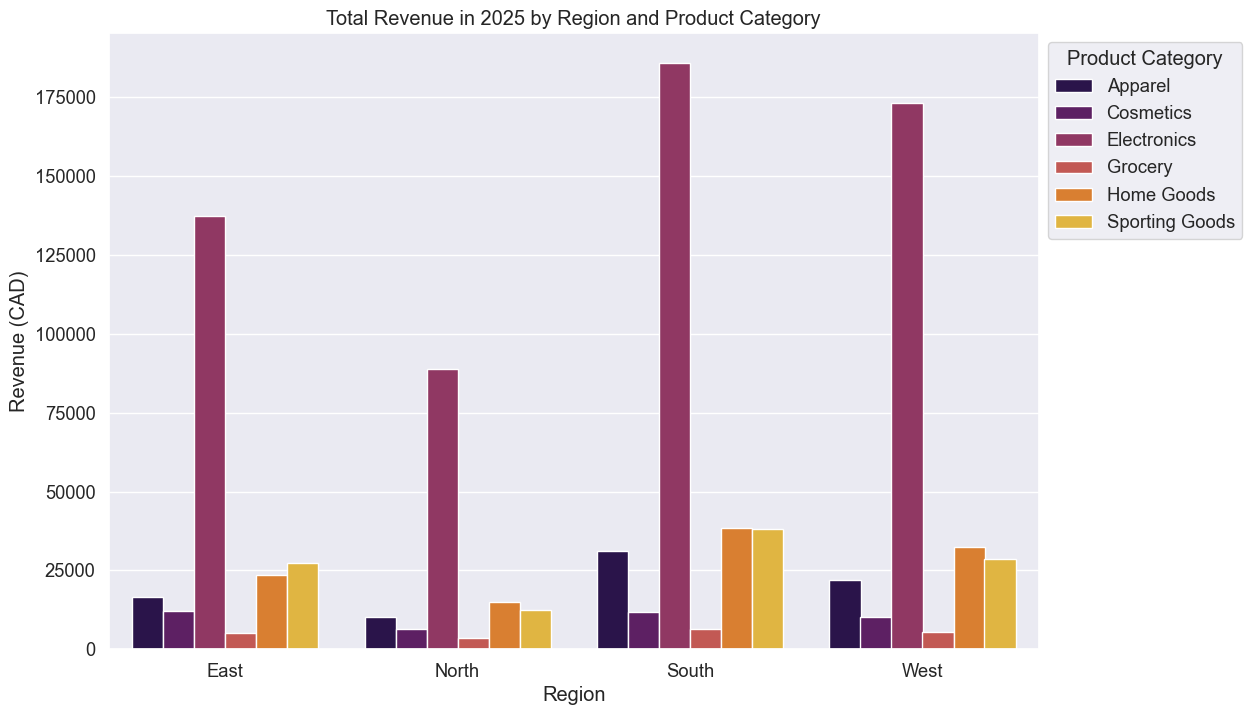

In [800]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (12, 8))

# plot using seaborn's heatmap
sns.barplot(
    data = region_category_profit,
    x = "Region",
    y = "Revenue",
    hue = "Product Category",
    palette = "inferno"
)

# change graph and axes titles
plt.title("Total Revenue in 2025 by Region and Product Category")
plt.xlabel("Region")
plt.ylabel("Revenue (CAD)")

# move legend to the right side outside the plot
plt.legend(
    title = "Product Category",
    loc = "upper left",
    bbox_to_anchor = (1, 1)
)

#### Revenue by Month

In [890]:
# calculate total monthly revenue
monthly_revenue = (
    business_clean
    .dropna(subset = ["sale_date"])
    .set_index("sale_date")
    .resample("MS")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,sale_date,revenue
0,2025-01-01,157163.43
1,2025-02-01,119899.49
2,2025-03-01,146406.68
3,2025-04-01,155587.57
4,2025-05-01,177628.53
5,2025-06-01,165242.41


Text(0, 0.5, 'Revenue (CAD)')

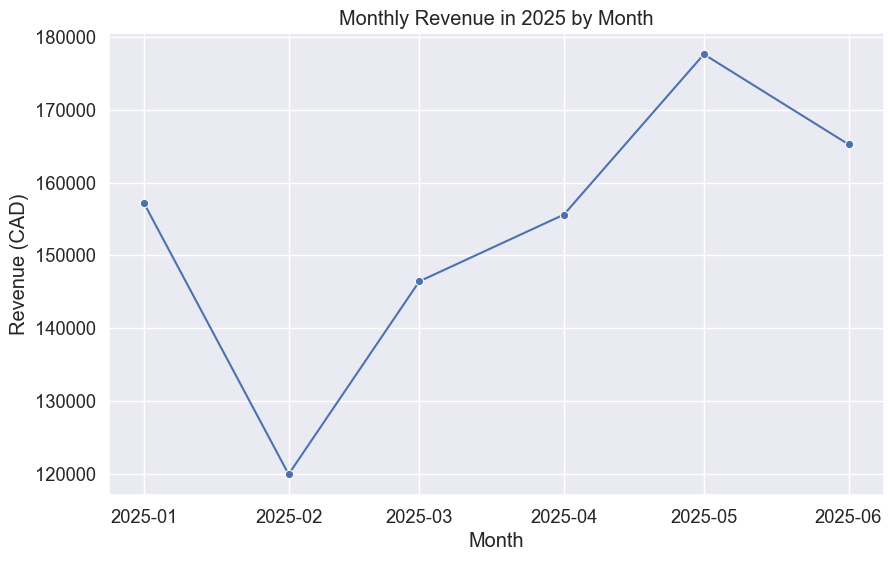

In [864]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (10, 6))

# plot monthly revenue
sns.lineplot(
    data = monthly_revenue,
    x = "sale_date",
    y = "revenue",
    marker = "o"
)

# change graph and axis titles
plt.title("Monthly Revenue in 2025 by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (CAD)")

#### Monthly Revenue by Region

In [ ]:
# ensure date is in datetime
business_clean["sale_date"] = pd.to_datetime(
    business_clean["sale_date"],
    errors = "coerce"
)

# create monthly column
business_clean["month"] = (
    business_clean["sale_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [889]:
# calculate monthly revenue by region
monthly_revenue_region = (
    business_clean
    .groupby(
        ["month", "region_sales"],
        as_index = False
    )["revenue"]
    .sum()
)

monthly_revenue_region

,month,region_sales,revenue
0,2025-01-01,east,30368.26
1,2025-01-01,north,21364.65
2,2025-01-01,south,57280.11
3,2025-01-01,west,48150.41
4,2025-02-01,east,31110.90
5,2025-02-01,north,19015.45
6,2025-02-01,south,36390.89
7,2025-02-01,west,33382.25
8,2025-03-01,east,41424.53
9,2025-03-01,north,18058.42


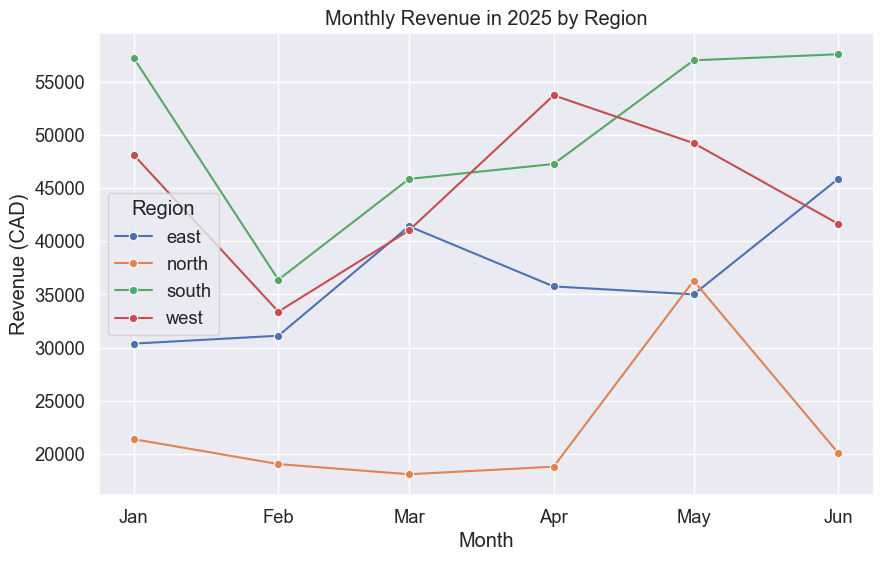

In [882]:
# set plot dimensions
sns.set_theme(font_scale=1.2)
plt.figure(figsize=(10, 6))

# plot monthly revenue by region
sns.lineplot(
    data = monthly_revenue_region,
    x = "month",
    y = "revenue",
    hue = "region_sales",
    marker = "o"
)

# change axis titles and labels
plt.title("Monthly Revenue in 2025 by Region")
plt.xlabel("Month")
plt.ylabel("Revenue (CAD)")
plt.legend(title = "Region")

# format x axis labels as month names
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

#### Monthly Revenue by Product Category

In [885]:
# monthly revenue
monthly_revenue_category = (
    business_clean
    .groupby(
        ["month", "product_category"],
        as_index = False
    )["revenue"]
    .sum()
)

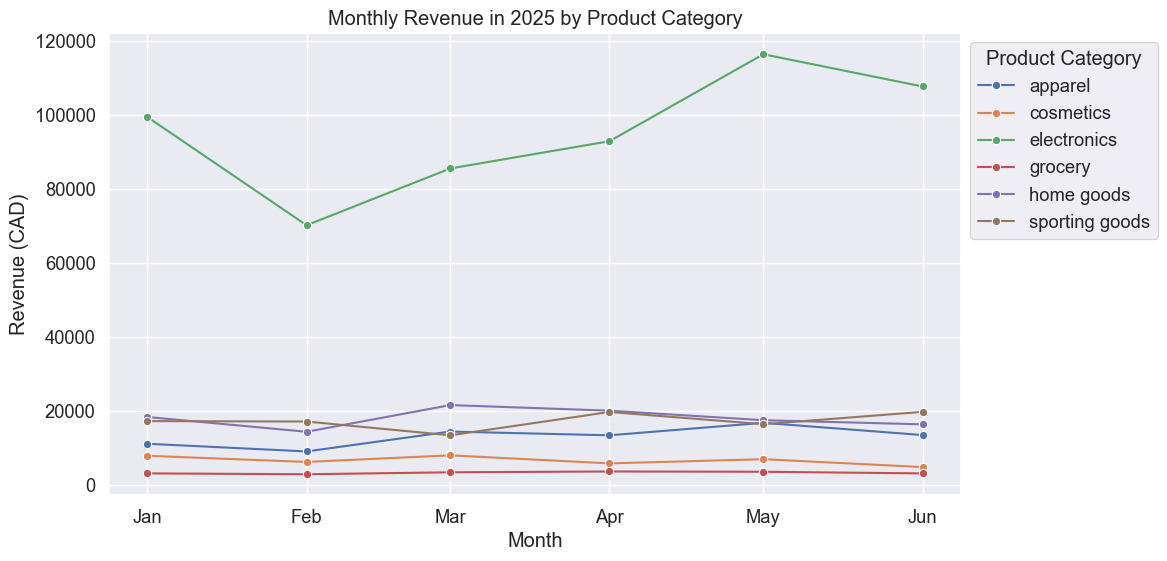

In [886]:
# set plot dimensions
sns.set_theme(font_scale = 1.2)
plt.figure(figsize = (11, 6))

# plot monthly revenue by category
sns.lineplot(
    data = monthly_revenue_category,
    x = "month",
    y = "revenue",
    hue = "product_category",
    marker = "o"
)

# change axis title and labels
plt.title("Monthly Revenue in 2025 by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue (CAD)")
plt.legend(
    title = "Product Category",
    loc = "upper left",
    bbox_to_anchor = (1, 1)
)

# format x labels as month names
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

### Consulting Summary

#### Main Findings

1. **Electronics drive the business but not proportionally as much profit** - Electronic generated around $580,000 in revenue (the most of any category) and also produced the greatest total profit at around $140,000. However, electronics contributed to 62% of total revenue but only around 45% of total profit, suggesting that the company is heavily dependent on electronic sales, but those sales may not be converting into profit as efficiently.

2. **Sporting goods slightly outperform home goods on profit despite lower revenue** - Home goods generates slightly more revenue than sporting goods (around $110,000 vs. $107,000), but sporting goods produces slightly more profit (around $51,000 vs. $49,000). This suggests that sporting goods may have a better markup or lower unit costs (compared to unit prices).

3. **Store types seem to influence regional revenue patterns** - Outlet stores are especially important in the West, while the South benefits from a more diversified mix of mall, outlet and street locations. However, total revenue alone cannot determine which store type performs best because differences may be due to the number of stores in each region (4).

4. **Regional profit differences are strongly related to store count** - The ranking for total gross profit closely follows the number of stores suggesting that regional profit is largely driven by regional scale. The South earns the most profit and has the most stores, while the North earns the least and has the least stores.

5. **Revenue changes drastically throughout the first half of 2025** - May is the month with the highest revenue ($178,000) while February is the month with the lowest revenue ($120,000). Further investigation is needed to determine the causes of the February decline and May peak (e.g. promotions, customer finances, season) though analysis of other plots may suggest a large reduction in electronics revenue.

6. **The South region is the strongest region consistently**.

7. **Revenue generated by electronics is drastically higher than every other category and almost follows the same pattern as total company revenue**.

#### Suggestions for the Business
1. Focus on electronics since it is the main driver of revenue
2. The south has the best performance so consider opening stores in that region
3. Target February to promote revenue increase (e.g. marketing strategies, promotions)